In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import sparse  # 引入稀疏矩阵
from scipy.sparse.linalg import spsolve
import seaborn as sns

sns.set_theme(style="whitegrid",context="talk")
CUT_MIN = 500
CUT_MAX = 1800

TARGET_POINTS = 896
WN_REF = np.linspace(CUT_MIN, CUT_MAX, TARGET_POINTS)

ASLS_LAM = 1e5
ASLS_P = 0.01
ASLS_MAX_ITER = 10
BAD_BANDS = [(900,928)]
EPS = 1e-8

def AsLS(spectrum, lam=1e5, p=0.01, niter=10, valid_mask=None):
    L = len(spectrum)
    D = sparse.diags([1, -2, 1], [0, -1, -2], shape=(L, L-2))
    w = np.ones(L)

    # ---- 若提供有效掩码：坏段权重恒为 0（不参与基线拟合）----
    if valid_mask is not None:
        valid_mask = np.asarray(valid_mask, dtype=bool)
        w[~valid_mask] = 0.0

    for _ in range(niter):
        W = sparse.diags(w, 0)
        Z = W + lam * D @ D.T
        baseline = spsolve(Z, w * spectrum)

        w = p * (spectrum > baseline) + (1 - p) * (spectrum < baseline)

        # ---- 每次迭代都保持坏段权重为 0 ----
        if valid_mask is not None:
            w[~valid_mask] = 0.0

    return baseline

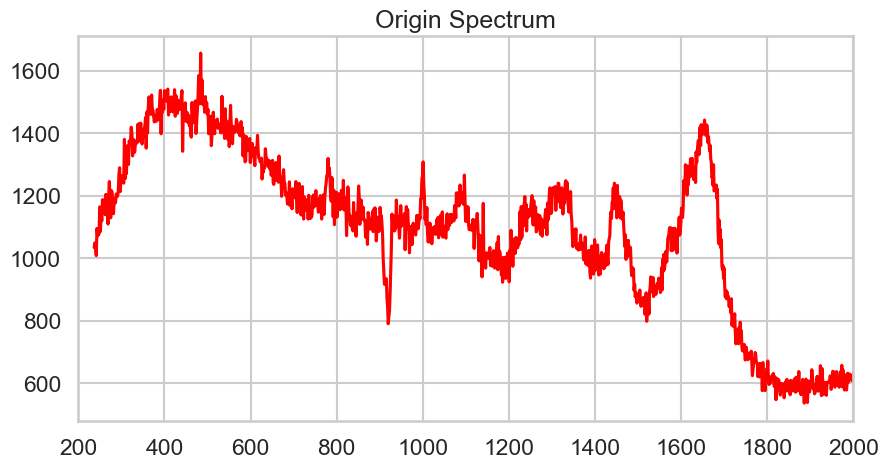

In [7]:
path = "dataset_raw/Family1/Klebsiella/KP/KP04_cell4_Area01_000_shift_cos.arc_data"

raw_wn = []
raw_sp = []

with open(path,"r",encoding="utf-8",errors="ignore") as f:
    for line in f:
        parts = line.strip().split()
        if len(parts)>=2:
            try:
                wn = float(parts[0])
                it = float(parts[1])
                raw_wn.append(wn)
                raw_sp.append(it)
            except:
                continue

wn = np.array(raw_wn)
sp = np.array(raw_sp)
plt.figure(figsize=(10,5))

plt.plot(wn, sp, color='red')
plt.xlim([200,2000])
plt.title("Origin Spectrum")
plt.show()

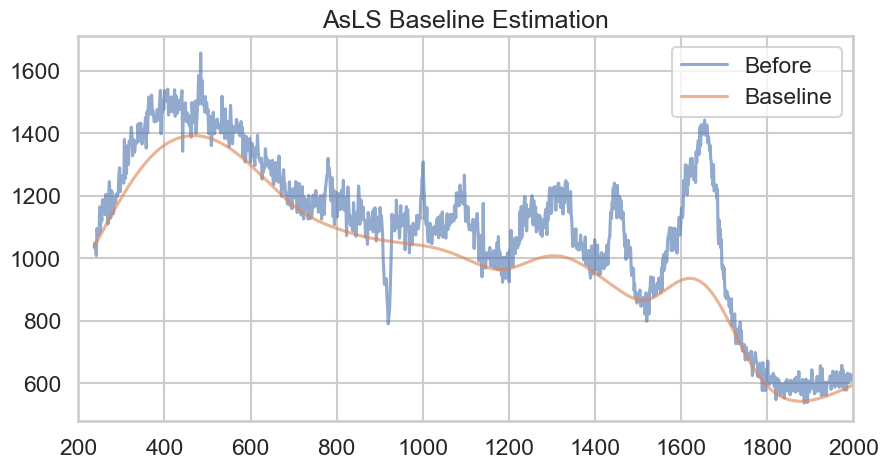

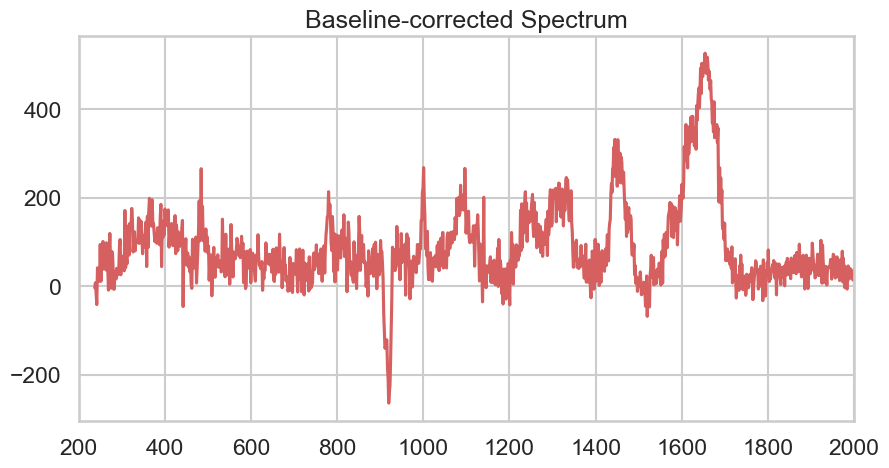

In [8]:
valid_mask = np.ones_like(wn, dtype=bool)
for (b0, b1) in BAD_BANDS:
    valid_mask &= ~((wn >= b0) & (wn <= b1))

baseline = AsLS(
    sp,
    lam=ASLS_LAM,
    p=ASLS_P,
    niter=ASLS_MAX_ITER,
    valid_mask=valid_mask
)
sp_bc = sp - baseline


plt.figure(figsize=(10,5))
plt.plot(wn, sp, label='Before', alpha=0.6)
plt.plot(wn, baseline, label='Baseline', alpha=0.6)
plt.legend()
plt.xlim([200,2000])
plt.legend()
plt.title("AsLS Baseline Estimation")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(wn, sp_bc, color = sns.color_palette("muted")[3])
plt.xlim([200,2000])
plt.title("Baseline-corrected Spectrum")
plt.show()

裁切后波数范围: 501.113 → 1799.978
裁切后长度: 926


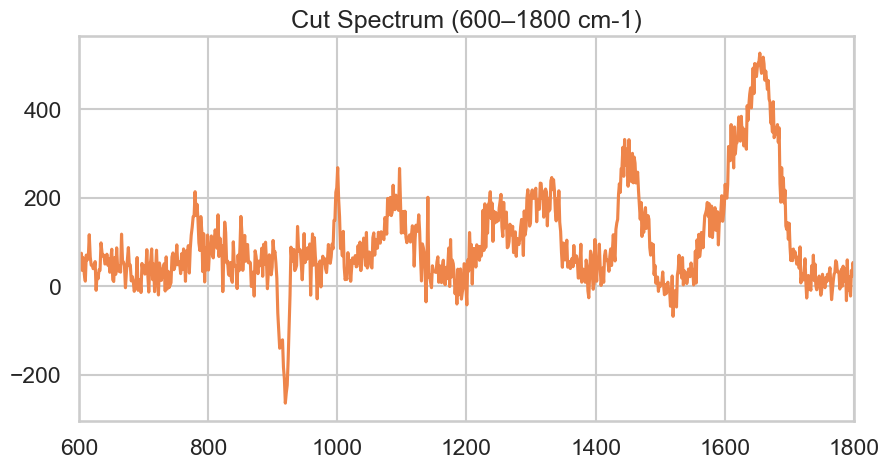

In [9]:
# ---- 裁切 600～1800 cm-1 波段 ----
# 创建波段掩码
mask_cut = (wn >= CUT_MIN) & (wn <= CUT_MAX)
wn_cut = wn[mask_cut]
sp_cut = sp_bc[mask_cut]

print("裁切后波数范围:", wn_cut[0], "→", wn_cut[-1])
print("裁切后长度:", len(sp_cut))

# ---- 绘图检查 ----
plt.figure(figsize=(10,5))
plt.plot(wn_cut, sp_cut, color = sns.color_palette("muted")[1])
plt.title("Cut Spectrum (600–1800 cm-1)")
plt.xlim([600,1800])
plt.show()


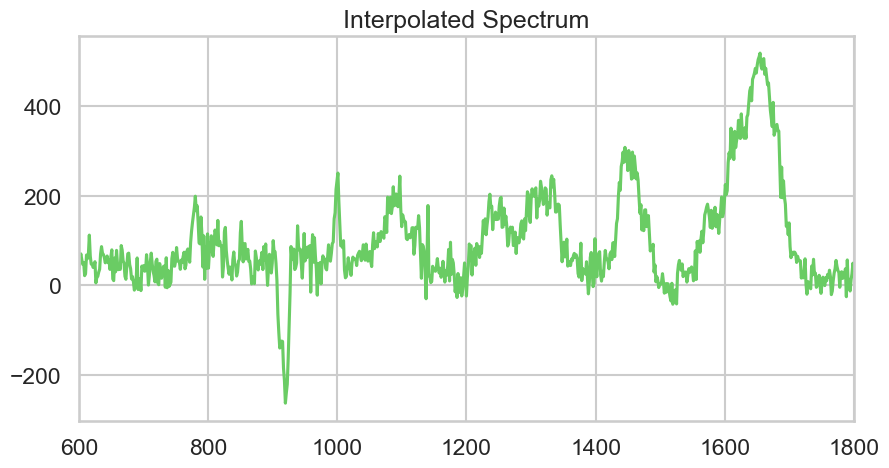

Final input shape: (896,)


In [10]:
wn_uniform = WN_REF.copy()

# 对裁切后的光谱做插值
sp_interp = np.interp(wn_uniform, wn_cut, sp_cut)

plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_interp, color = sns.color_palette("muted")[2])
plt.title("Interpolated Spectrum")
plt.xlim([600,1800])
plt.show()

print("Final input shape:", sp_interp.shape)

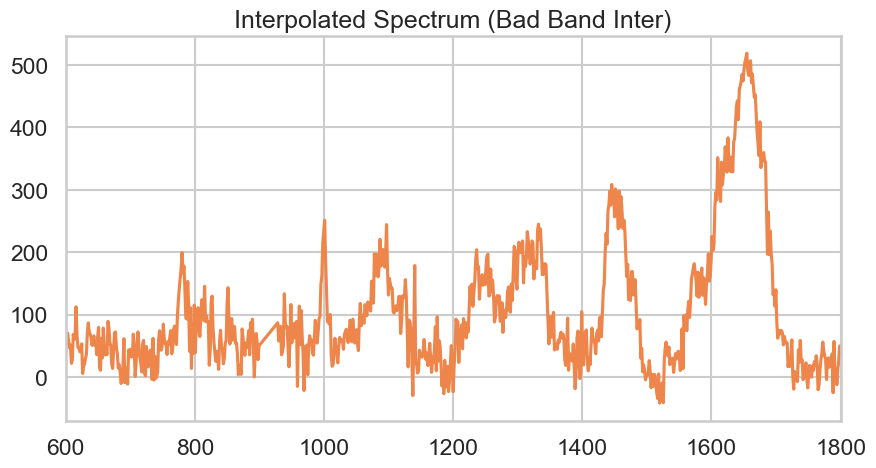

In [11]:
sp_linear = sp_interp.copy()
for (b0, b1) in BAD_BANDS:
    # 找到坏区间的左右边界索引
    idx_bad = (wn_uniform >= b0) & (wn_uniform <= b1)

    # 如果坏区间由于切个别点导致没有覆盖到任何点，跳过
    if not np.any(idx_bad):
        continue

    # 找到坏区间左侧最近的一个有效点索引
    left_indices = np.where(wn_uniform < b0)[0]
    # 找到坏区间右侧最近的一个有效点索引
    right_indices = np.where(wn_uniform > b1)[0]

    # 只有左右都有点时才能插值，否则只能填0或边缘值
    if len(left_indices) > 0 and len(right_indices) > 0:
        idx_left = left_indices[-1]
        idx_right = right_indices[0]

        val_left = sp_linear[idx_left]
        val_right = sp_linear[idx_right]

        # 线性插值公式
        # y = y1 + (x - x1) * (y2 - y1) / (x2 - x1)
        x_range = wn_uniform[idx_bad]
        x_left, x_right = wn_uniform[idx_left], wn_uniform[idx_right]

        sp_linear[idx_bad] = val_left + \
                             (x_range - x_left) * (val_right - val_left) / (x_right - x_left)
    else:
        # 如果处于边缘（极少情况），可以填 0
        sp_linear[idx_bad] = 0.0

plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_linear, color = sns.color_palette("muted")[1])
plt.title("Interpolated Spectrum (Bad Band Inter)")
plt.xlim([600,1800])
plt.show()

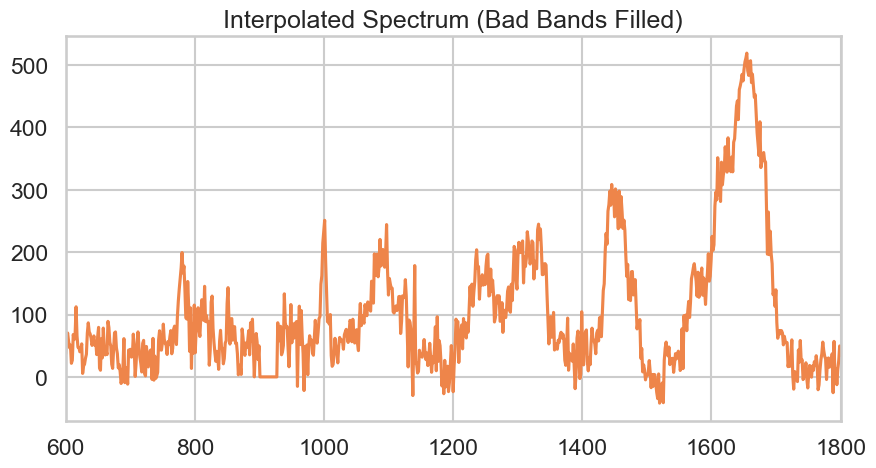

In [12]:
sp_filled = sp_interp.copy()

for (b0, b1) in BAD_BANDS:
    bad_mask = (wn_uniform >= b0) & (wn_uniform <= b1)
    sp_filled[bad_mask] = 0.0

plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_filled, color=sns.color_palette("muted")[1])
plt.title("Interpolated Spectrum (Bad Bands Filled)")
plt.xlim([600, 1800])
plt.show()

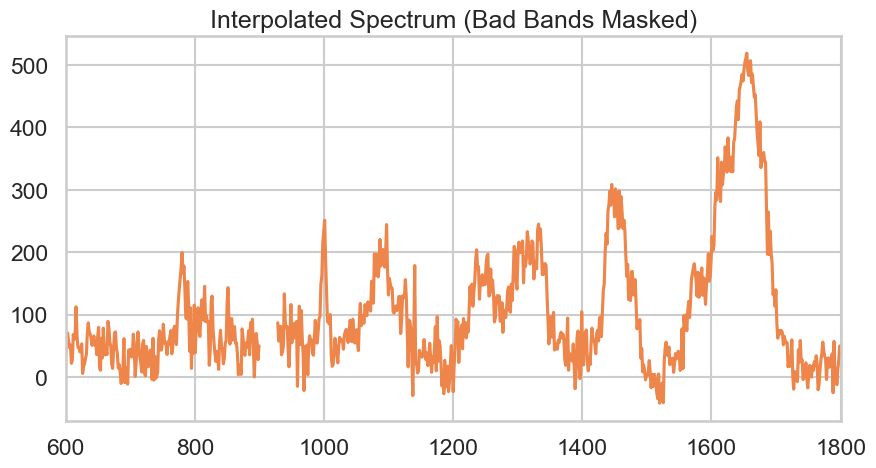

In [13]:
keep_mask = np.ones_like(wn_uniform, dtype=bool)
sp_delete = sp_interp.copy()

for (b0, b1) in BAD_BANDS:
    bad_mask = (wn_uniform >= b0) & (wn_uniform <= b1)
    sp_delete[bad_mask] = np.nan

wn_uniform = wn_uniform[keep_mask]
sp_interp  = sp_interp[keep_mask]

plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_delete, color=sns.color_palette("muted")[1])
plt.title("Interpolated Spectrum (Bad Bands Masked)")
plt.xlim([600, 1800])
plt.show()


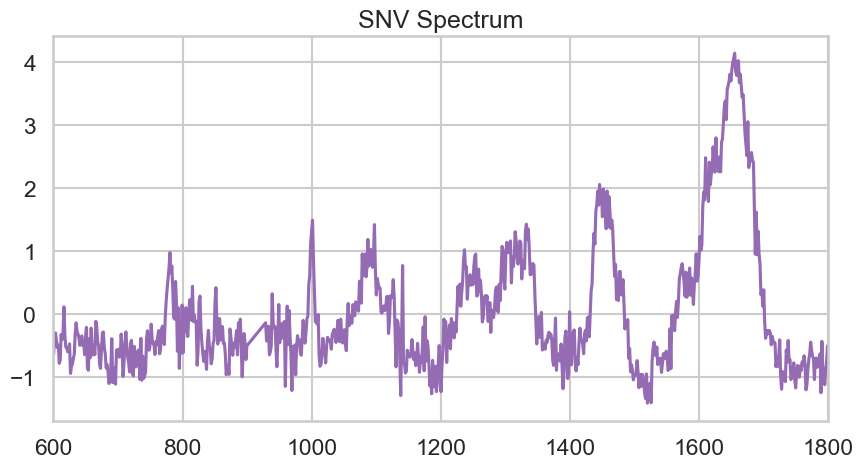

In [14]:
keep_mask = np.ones_like(wn_uniform, dtype=bool)
for (b0, b1) in BAD_BANDS:
    keep_mask &= ~((wn_uniform >= b0) & (wn_uniform <= b1))

wn_uniform = wn_uniform[keep_mask]
sp_interp  = sp_interp[keep_mask]

def SNV(X):
    mean = np.mean(X)
    std = np.std(X)
    return (X - mean) / (std + EPS)

sp_snv = SNV(sp_interp)
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_snv, color=sns.color_palette("muted")[4])
plt.title("SNV Spectrum")
plt.xlim([600,1800])
plt.show()

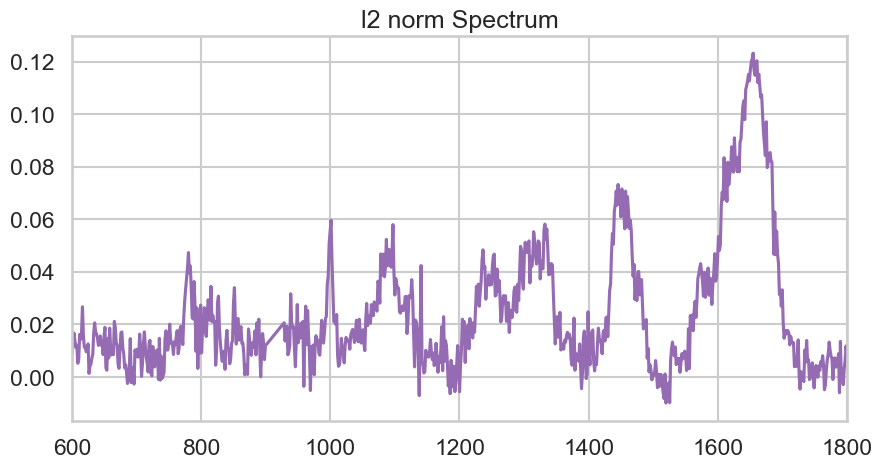

In [15]:
keep_mask = np.ones_like(wn_uniform, dtype=bool)
for (b0, b1) in BAD_BANDS:
    keep_mask &= ~((wn_uniform >= b0) & (wn_uniform <= b1))

wn_uniform = wn_uniform[keep_mask]
sp_interp  = sp_interp[keep_mask]

def L2Normalize(x, eps=1e-8):
    """
    L2 标准化（逐样本）
    作用：
    - 消除整体强度尺度
    - 保留谱形方向（峰相对结构）
    - 不强制零均值
    - NaN-safe（物理无效区不参与）
    """
    x = np.asarray(x, dtype=np.float32)
    mask = np.isfinite(x)
    if not mask.any():
        return x

    norm = np.sqrt(np.sum(x[mask] ** 2))
    norm = max(norm, eps)

    out = x.copy()
    out[mask] = out[mask] / norm
    return out

sp_l2 = L2Normalize(sp_interp)
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_l2, color=sns.color_palette("muted")[4])
plt.title("l2 norm Spectrum")
plt.xlim([600,1800])
plt.show()

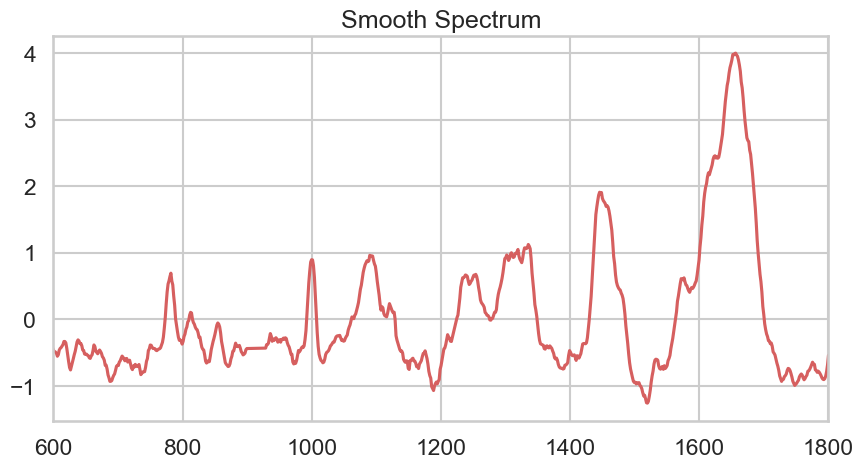

In [16]:
from scipy.signal import savgol_filter
delta = wn_uniform[1] - wn_uniform[0]
smooth = savgol_filter(sp_snv, window_length=15, polyorder=3)
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, smooth, color=sns.color_palette("muted")[3])
plt.title("Smooth Spectrum")
plt.xlim([600,1800])
plt.show()

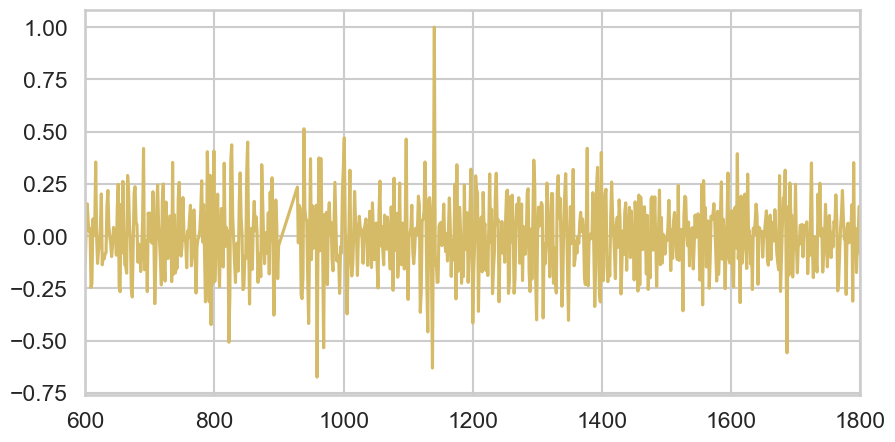

In [17]:
sp_res = sp_interp - savgol_filter(sp_interp, window_length=15, polyorder=3)

scale = np.maximum(np.max(np.abs(sp_res)), EPS)
sp_res = sp_res / scale
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_res, color=sns.color_palette("muted")[8])
plt.xlim([600,1800])
plt.show()

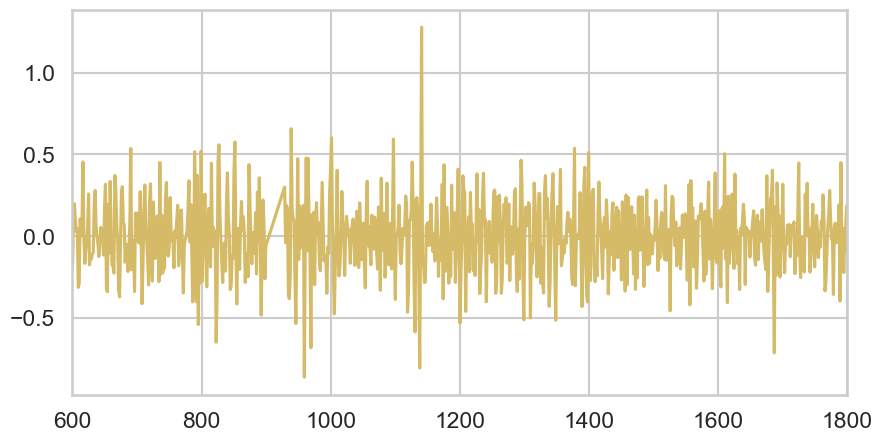

In [18]:
sp_res = sp_snv - smooth
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, sp_res, color=sns.color_palette("muted")[8])
plt.xlim([600,1800])
plt.show()

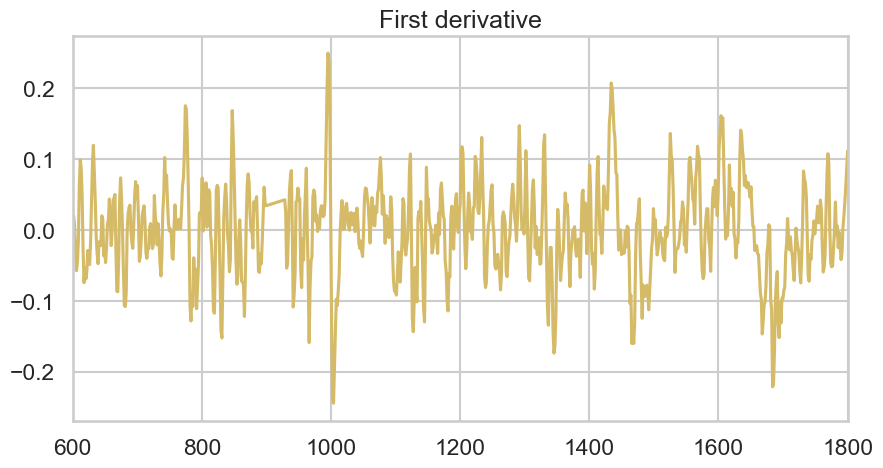

In [19]:
delta = wn_uniform[1] - wn_uniform[0]
d1 = savgol_filter(sp_snv, window_length=11, polyorder=3, deriv=1, delta=delta)
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, d1, color=sns.color_palette("muted")[8])
plt.xlim([600,1800])
plt.title("First derivative")
plt.show()

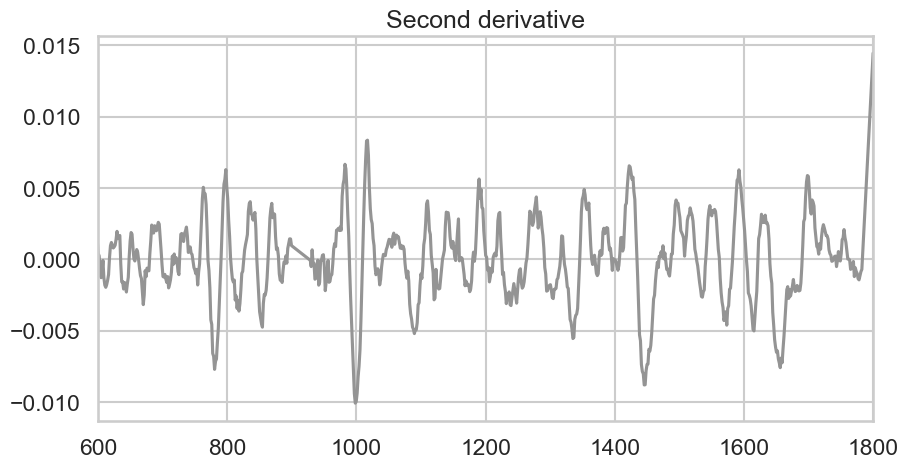

In [20]:
d2 = savgol_filter(sp_snv, window_length=25, polyorder=3, deriv=2, delta=delta)
plt.figure(figsize=(10,5))
plt.plot(wn_uniform, d2, color=sns.color_palette("colorblind")[7])
plt.title("Second derivative")
plt.xlim([600,1800])
plt.show()